库导入完成
训练图片数量: 209
测试图片数量: 50


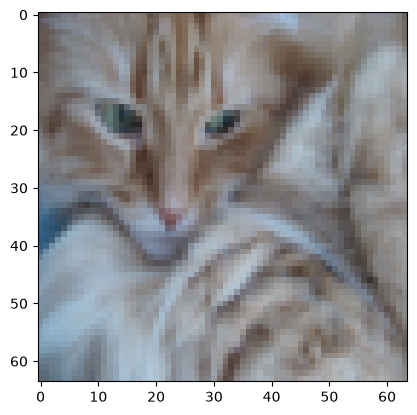

标签: [1]
展平后训练数据shape： (12288, 209)
w shape: (12288, 1)
b = 0
Iter 0 , Cost: 0.6931471805599453
Iter 100 , Cost: 0.5845083636993086
Iter 200 , Cost: 0.46694904094655476
Iter 300 , Cost: 0.3760068669480208
Iter 400 , Cost: 0.3314632893282512
Iter 500 , Cost: 0.30327306747438293
Iter 600 , Cost: 0.27987958658260487
Iter 700 , Cost: 0.2600421369258757
Iter 800 , Cost: 0.2429406846779662
Iter 900 , Cost: 0.22800422256726063
Iter 1000 , Cost: 0.2148195137844964
Iter 1100 , Cost: 0.20307819060644985
Iter 1200 , Cost: 0.19254427716706868
Iter 1300 , Cost: 0.18303333796883509
Iter 1400 , Cost: 0.17439859438448874
Iter 1500 , Cost: 0.16652139705400332
Iter 1600 , Cost: 0.15930451829756614
Iter 1700 , Cost: 0.15266732471296507
Iter 1800 , Cost: 0.14654223503982336
Iter 1900 , Cost: 0.1408720757031016
训练集准确率: 99.04306220095694 %
测试集准确率: 70.0 %


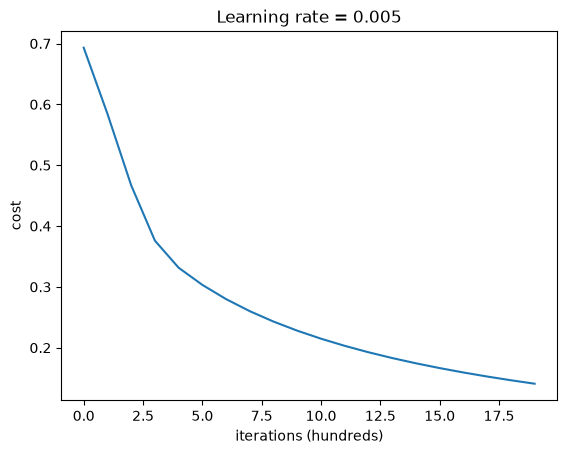

In [2]:
# 使用逻辑回归完成猫咪图片二分类
# 1. 导入库
import numpy as np
import matplotlib.pyplot as plt
import h5py
import os
print("库导入完成")

# 2. 加载数据集（适配你的目录结构，跨电脑通用）
def load_dataset():
    # 获取当前工作目录
    current_dir = os.getcwd()
    # 判断是否处于notebooks文件夹，自动向上跳转一级
    if os.path.basename(current_dir) == "notebooks":
        base_path = os.path.dirname(current_dir)
    else:
        base_path = current_dir
        
    train_path = os.path.join(base_path, "datasets", "train_catvnoncat.h5")
    test_path = os.path.join(base_path, "datasets", "test_catvnoncat.h5")

    train_dataset = h5py.File(train_path, "r")
    train_set_x_orig = np.array(train_dataset["train_set_x"][:])
    train_set_y_orig = np.array(train_dataset["train_set_y"][:])
    
    test_dataset = h5py.File(test_path, "r")
    test_set_x_orig = np.array(test_dataset["test_set_x"][:])
    test_set_y_orig = np.array(test_dataset["test_set_y"][:])
    
    classes = np.array(test_dataset["list_classes"][:])
    train_set_y_orig = train_set_y_orig.reshape((1, train_set_y_orig.shape[0]))
    test_set_y_orig = test_set_y_orig.reshape((1, test_set_y_orig.shape[0]))
    
    return train_set_x_orig, train_set_y_orig, test_set_x_orig, test_set_y_orig, classes


train_set_x_orig, train_set_y, \
test_set_x_orig, test_set_y, classes = load_dataset()

print("训练图片数量:", train_set_x_orig.shape[0])
print("测试图片数量:", test_set_x_orig.shape[0])


# =========================
# 3. 查看图片
# =========================
index = 2
plt.imshow(train_set_x_orig[index])
plt.show()
print("标签:", train_set_y[:, index])


# =========================
# 4. 图片数据处理
# =========================
train_set_x_flatten = train_set_x_orig.reshape(train_set_x_orig.shape[0], -1).T
test_set_x_flatten = test_set_x_orig.reshape(test_set_x_orig.shape[0], -1).T
print("展平后训练数据shape：", train_set_x_flatten.shape)


# =========================
# 5. 数据标准化
# =========================
train_set_x = train_set_x_flatten / 255.
test_set_x = test_set_x_flatten / 255.


# =========================
# 6. Sigmoid函数
# =========================
def sigmoid(z):
    s = 1 / (1 + np.exp(-z))
    return s


# =========================
# 7. 初始化参数
# =========================
def initialize_with_zeros(dim):
    w = np.zeros((dim, 1))
    b = 0
    return w, b

w, b = initialize_with_zeros(train_set_x.shape[0])
print("w shape:", w.shape)
print("b =", b)


# =========================
# 8. 前向传播 + 反向传播
# =========================
def propagate(w, b, X, Y):
    m = X.shape[1]
    # 前向传播
    A = sigmoid(np.dot(w.T, X) + b)
    cost = -1/m * np.sum(Y * np.log(A) + (1 - Y) * np.log(1 - A))
    # 反向传播
    dw = 1/m * np.dot(X, (A - Y).T)
    db = 1/m * np.sum(A - Y)
    cost = np.squeeze(cost)
    return dw, db, cost


# =========================
# 9. 梯度下降优化
# =========================
def optimize(w, b, X, Y, num_iterations, learning_rate, print_cost=False):
    costs = []
    for i in range(num_iterations):
        dw, db, cost = propagate(w, b, X, Y)
        # 参数更新
        w = w - learning_rate * dw
        b = b - learning_rate * db
        
        if i % 100 == 0:
            costs.append(cost)
            if print_cost:
                print(f"Iter {i} , Cost: {cost}")

    params = {"w": w, "b": b}
    grads = {"dw": dw, "db": db}
    return params, grads, costs


# =========================
# 10. 预测函数
# =========================
def predict(w, b, X):
    m = X.shape[1]
    Y_prediction = np.zeros((1, m))
    w = w.reshape(X.shape[0], 1)
    A = sigmoid(np.dot(w.T, X) + b)
    for i in range(A.shape[1]):
        if A[0, i] > 0.5:
            Y_prediction[0, i] = 1
        else:
            Y_prediction[0, i] = 0
    return Y_prediction


# =========================
# 11. 训练模型
# =========================
dim = train_set_x.shape[0]
w, b = initialize_with_zeros(dim)
params, grads, costs = optimize(
    w, b, train_set_x, train_set_y,
    num_iterations=2000,
    learning_rate=0.005,
    print_cost=True
)

w = params["w"]
b = params["b"]

# =========================
# 12. 预测 & 评估
# =========================
Y_prediction_train = predict(w, b, train_set_x)
Y_prediction_test = predict(w, b, test_set_x)

print("训练集准确率: {} %".format(100 - np.mean(np.abs(Y_prediction_train - train_set_y)) * 100))
print("测试集准确率: {} %".format(100 - np.mean(np.abs(Y_prediction_test - test_set_y)) * 100))

# 绘制损失曲线
plt.plot(costs)
plt.ylabel('cost')
plt.xlabel('iterations (hundreds)')
plt.title("Learning rate = 0.005")
plt.show()